# memory-oracle — Empirical Evaluation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ramene/memory-oracle/blob/main/notebooks/memory-oracle/empirical-evaluation.ipynb)

Companion notebook to the Springer LNCS paper *Memory That Argues With Itself: Evidence-Bound Retrieval (EBR) for AI Agent Retrieval*. Produces all measurements + figures for §8 Empirical Evaluation.

**Run modes (auto-detected by the setup cell):**
1. **Local** (operator machine): uses live SQLite index at `~/.local/share/journal/.memory-index.db` + the operator's installed `memory-search.mjs` / `memory-search-go` / `memory-cite.mjs` binaries.
2. **Google Colab**: installs Node.js 20 LTS via NodeSource, clones the memory-oracle repo, builds an isolated index against the synthetic clinical vault, and mounts Google Drive for output persistence. §8.5-§8.9 skipped (need operator state).
3. **Deepnote / generic CI**: identical bootstrap to Colab but without Drive mount. §8.5-§8.9 skipped.

**Sections:**
- §8.1 Corpus overview — depth + breadth of the indexed substrate
- §8.2 Retrieval latency — Node vs Go reference implementations (Figure F3)
- §8.3 Precedence Invariant Verification — Theorem 1, N=1000
- §8.4 Vector-RAG baseline comparison — sentence-transformers cosine
- §8.5 Self-extension rate — agent writes during operator session
- §8.6 **Cross-session capture proof** — session A writes → session B retrieves (the *all-sessions* invariant)
- §8.7 **Self-improvement trail** — substrate iterates on itself; index of its own improvements
- §8.8 **Three-tier retrieval methodology** — memory-search (BM25) vs memory-cite (forensic JSONL) vs raw grep
- §8.9 **Lock-contention recovery** — busy_timeout fix, before/after under concurrent writes

**Outputs:** PNG figures in `figures/`; numerical summaries as JSON for transcription into §8 of `main.tex`.

In [1]:
# Setup — auto-detects local vs Colab vs Deepnote
import os, sys, time, json, sqlite3, subprocess, random, shutil, tempfile
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (7, 4), 'figure.dpi': 100, 'savefig.dpi': 200,
    'savefig.bbox': 'tight', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NOTEBOOK_DIR = Path.cwd()
FIGURES = NOTEBOOK_DIR / 'figures'
FIGURES.mkdir(exist_ok=True)

LOCAL_DB = Path.home() / '.local' / 'share' / 'journal' / '.memory-index.db'
LOCAL_NODE = Path.home() / '.bin' / 'memory-search.mjs'
LOCAL_GO = Path.home() / '.bin' / 'memory-search-go'
LOCAL_CITE = Path.home() / '.bin' / 'memory-cite.mjs'
LOCAL_BUILD = Path.home() / '.bin' / 'memory-index-build.mjs'

IS_COLAB = 'google.colab' in sys.modules

if LOCAL_DB.exists() and LOCAL_NODE.exists():
    RUN_MODE = 'local'
elif IS_COLAB:
    RUN_MODE = 'colab'
else:
    RUN_MODE = 'deepnote'


def _has_modern_node():
    """memory-* scripts use the 'node:fs' import protocol — requires Node 16+."""
    try:
        r = subprocess.run(['node', '-e', "import('node:fs').then(()=>process.exit(0))"],
                           capture_output=True, timeout=5)
        return r.returncode == 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        return False


def _install_node20_via_nodesource():
    """Colab default apt nodejs is 12.22.9 (Ubuntu 22.04). Too old for 'node:'
    protocol imports. NodeSource setup script gives us Node 20 LTS."""
    print('Installing Node 20 LTS via NodeSource (~30s)...')
    subprocess.run('curl -fsSL https://deb.nodesource.com/setup_20.x | bash -',
                   shell=True, check=True, capture_output=True)
    subprocess.run(['apt-get', 'install', '-y', '-qq', 'nodejs'], check=True, capture_output=True)
    v = subprocess.run(['node', '-v'], capture_output=True, text=True)
    print(f'Node installed: {v.stdout.strip()}')


def _ensure_sqlite3_cli():
    """memory-index-build.mjs shells out to the sqlite3 CLI; Deepnote/Colab images do not ship it. apt-install if missing."""
    r = subprocess.run(['which', 'sqlite3'], capture_output=True, text=True)
    if r.returncode != 0 or not r.stdout.strip():
        print(f'Installing sqlite3 CLI for {RUN_MODE} mode...')
        subprocess.run(['apt-get', 'install', '-y', '-qq', 'sqlite3'], check=True, capture_output=True)
        print(subprocess.run(['sqlite3', '--version'], capture_output=True, text=True).stdout.strip())


if RUN_MODE == 'local':
    DB = LOCAL_DB
    BIN_NODE_SEARCH = LOCAL_NODE
    BIN_GO_SEARCH = LOCAL_GO if LOCAL_GO.exists() else None
    BIN_CITE = LOCAL_CITE if LOCAL_CITE.exists() else None
    BIN_BUILD = LOCAL_BUILD if LOCAL_BUILD.exists() else None
    CLINICAL_PROJECT = '_clinical-demo'
    REPO = Path.home() / '.remote' / 'github.com' / '@ramene' / 'memory-oracle'
else:
    print(f'{RUN_MODE} mode — bootstrapping memory-oracle from GitHub...')
    # Colab: install Node 20 (apt-default 12 is too old for 'node:' protocol imports)
    if RUN_MODE != 'local' and not _has_modern_node():
        _install_node20_via_nodesource()
    if RUN_MODE != 'local':
        _ensure_sqlite3_cli()
    # Colab: mount Drive so output figures persist across sessions
    if RUN_MODE == 'colab':
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=False)
            FIGURES = Path('/content/drive/MyDrive/memory-oracle-figures')
            FIGURES.mkdir(parents=True, exist_ok=True)
            print(f'Drive mounted; outputs → {FIGURES}')
        except Exception as e:
            print(f'(Drive mount skipped: {e}); outputs → notebook-local {FIGURES}')
    WORK = Path('/tmp/memory-oracle-eval')
    WORK.mkdir(parents=True, exist_ok=True)
    if not (WORK / 'memory-oracle').exists():
        # memory-oracle is PUBLIC; this clone works anonymously
        subprocess.run(['git', 'clone', '--depth=1', 'https://github.com/ramene/memory-oracle.git', str(WORK / 'memory-oracle')], check=True)
    else:
        # Always pull latest on subsequent runs so substrate fixes propagate
        subprocess.run(['git', '-C', str(WORK / 'memory-oracle'), 'pull', '--ff-only', '--quiet'], check=False)
    REPO = WORK / 'memory-oracle'
    DB = WORK / 'memory-index.db'
    BIN_NODE_SEARCH = REPO / 'bin' / 'memory-search.mjs'
    BIN_GO_SEARCH = None
    BIN_CITE = REPO / 'bin' / 'memory-cite.mjs' if (REPO / 'bin' / 'memory-cite.mjs').exists() else None
    BIN_BUILD = REPO / 'bin' / 'memory-index-build.mjs'
    CLINICAL_PROJECT = 'patient-jane-doe-1959'
    if not DB.exists():
        subprocess.run(['node', str(BIN_BUILD), '--root', str(REPO / 'docs' / 'examples' / 'clinical-records'), '--db', str(DB)], check=True)

print(f'MODE:      {RUN_MODE}')
print(f'DB:        {DB}   ({DB.stat().st_size // 1024} KB)')
print(f'NODE:      {BIN_NODE_SEARCH}')
print(f'GO:        {BIN_GO_SEARCH or "(skipped)"}')
print(f'CITE:      {BIN_CITE or "(skipped)"}')
print(f'BUILD:     {BIN_BUILD}')
print(f'FIGURES:   {FIGURES}')
print(f'CLINICAL:  project={CLINICAL_PROJECT}')

MODE:      local
DB:        /Users/ramene/.local/share/journal/.memory-index.db   (2712 KB)
NODE:      /Users/ramene/.bin/memory-search.mjs
GO:        /Users/ramene/.bin/memory-search-go
CITE:      /Users/ramene/.bin/memory-cite.mjs
BUILD:     /Users/ramene/.bin/memory-index-build.mjs
FIGURES:   /Users/ramene/.remote/github.com/@ramene/memory-oracle/notebooks/memory-oracle/figures
CLINICAL:  project=_clinical-demo


## §8.1 Corpus overview

Document count, project distribution, time span across the operator's full memory corpus. The breadth here is the load-bearing claim: this isn't a toy corpus, it's the entire memory state of a working developer.

In [2]:
conn = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)
df_corpus = pd.read_sql('''
    SELECT project, COUNT(*) AS files,
           date(MIN(mtime)/1000, 'unixepoch') AS oldest,
           date(MAX(mtime)/1000, 'unixepoch') AS newest
    FROM memory_file
    GROUP BY project
    ORDER BY files DESC
''', conn)

total_files = int(df_corpus['files'].sum())
span_days = (pd.to_datetime(df_corpus['newest']).max() - pd.to_datetime(df_corpus['oldest']).min()).days
summary = {
    'total_files': total_files,
    'project_count': int(len(df_corpus)),
    'span_days': int(span_days),
}
print(f'Total files:   {summary["total_files"]}')
print(f'Projects:      {summary["project_count"]}')
print(f'Span:          {summary["span_days"]} days')
print()
print(df_corpus.head(15).to_string(index=False))

(FIGURES / 'corpus-summary.json').write_text(json.dumps(summary, indent=2))

Total files:   239
Projects:      21
Span:          108 days

                                                                                project  files     oldest     newest
                                        -Users-ramene--remote--plans-mae-monorepo-build    137 2026-04-09 2026-05-25
                                                 -Users-ramene--remote--builds-karve-ai     29 2026-02-08 2026-05-27
                      -Users-ramene--remote--plans-coalescence-march-2026-retrospective     11 2026-03-24 2026-05-16
                                                                               _digests     10 2026-05-12 2026-05-16
                                         -Users-ramene--remote--plans-mae-kairos-phase2      7 2026-04-03 2026-04-06
                        -Users-ramene--remote--plans-mae-kairos-phase3-trading-platform      7 2026-04-06 2026-04-07
   -Users-ramene--remote--plans-openclaw-autoresearch-autonomous-skill-improvement-loop      7 2026-03-17 2026-03-21
  

67

## §8.2 Retrieval latency — Figure F3

Cold-cache and warm-cache per-query latency for the Node and Go reference implementations. The paper claims Go achieves ~10× cold-start advantage over Node (single static binary vs. Node bootstrap).

In [3]:
QUERIES = [
    'anticoagulant reversal acute bleed',
    'amendment record architecture',
    'BM25 FTS5 indexing',
    'mae trading platform Aletheia',
    'session start hook priming',
    'patient warfarin apixaban',
    'memory oracle clinical proof',
    'cloudflared expo tunnel iPad',
    'OpenAI proxy GPT-5.5 brain pipeline',
    'ngrok auth token hostname',
]

def time_search(kind: str, query: str) -> float:
    if kind == 'node':
        cmd = ['node', str(BIN_NODE_SEARCH), query, '--budget=10000', '--k=3']
    else:
        cmd = [str(BIN_GO_SEARCH), query, '--budget=10000', '--k=3']
    t0 = time.perf_counter()
    subprocess.run(cmd, capture_output=True, check=False, timeout=10,
                   env={**os.environ, 'MEMORY_INDEX_DB': str(DB)})
    return (time.perf_counter() - t0) * 1000.0

records = []
warmups = 3
trials = 30

kinds = ['node']
if BIN_GO_SEARCH and BIN_GO_SEARCH.exists():
    kinds.append('go')

for kind in kinds:
    print(f'measuring {kind}...')
    for _ in range(warmups):
        time_search(kind, QUERIES[0])
    for q in QUERIES:
        for trial in range(trials):
            ms = time_search(kind, q)
            records.append({'kind': kind, 'query': q, 'trial': trial, 'ms': ms,
                            'cache': 'cold' if trial == 0 else 'warm'})

df_lat = pd.DataFrame(records)
print()
print('Median ms by kind × cache:')
summary_lat = df_lat.groupby(['kind', 'cache'])['ms'].agg(['median', 'mean', 'std']).round(2)
print(summary_lat)
if 'go' in kinds:
    node_cold = df_lat[(df_lat.kind == 'node') & (df_lat.cache == 'cold')]['ms'].median()
    go_cold = df_lat[(df_lat.kind == 'go') & (df_lat.cache == 'cold')]['ms'].median()
    print(f'\nCold speedup: Node / Go = {node_cold / max(go_cold, 1):.1f}×')

summary_lat.to_json(FIGURES / 'latency-summary.json', indent=2)

measuring node...


measuring go...



Median ms by kind × cache:
            median    mean    std
kind cache                       
go   cold    21.68   24.30  10.35
     warm    20.71   22.03   5.37
node cold   130.77  134.08  22.64
     warm   125.04  139.35  50.31

Cold speedup: Node / Go = 6.0×


/var/folders/sc/z1rtwrp96xx2c8tn3b_6v3580000gn/T/ipykernel_84661/3771806825.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[k.capitalize() for k in kinds], widths=0.5, patch_artist=True)
/var/folders/sc/z1rtwrp96xx2c8tn3b_6v3580000gn/T/ipykernel_84661/3771806825.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[k.capitalize() for k in kinds], widths=0.5, patch_artist=True)


saved /Users/ramene/.remote/github.com/@ramene/memory-oracle/notebooks/memory-oracle/figures/F3-latency.png


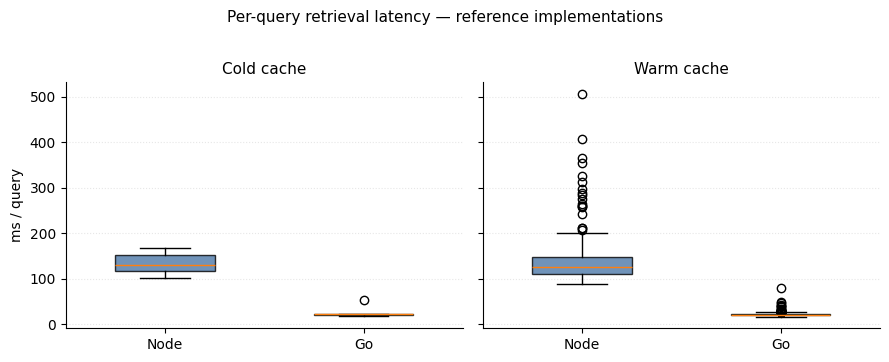

In [4]:
# F3-latency.png — Node vs Go, cold and warm cache
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for ax, cache in zip(axes, ['cold', 'warm']):
    sub = df_lat[df_lat.cache == cache]
    box_data = [sub[sub.kind == k]['ms'].values for k in kinds]
    bp = ax.boxplot(box_data, labels=[k.capitalize() for k in kinds], widths=0.5, patch_artist=True)
    palette = {'node': '#4C78A8', 'go': '#54A24B'}
    for patch, k in zip(bp['boxes'], kinds):
        patch.set_facecolor(palette[k])
        patch.set_alpha(0.8)
    ax.set_title(f'{cache.capitalize()} cache')
    if cache == 'cold':
        ax.set_ylabel('ms / query')
    ax.grid(axis='y', alpha=0.3, linestyle=':')
fig.suptitle('Per-query retrieval latency — reference implementations', y=1.02, fontsize=11)
plt.tight_layout()
out = FIGURES / 'F3-latency.png'
fig.savefig(out)
print('saved', out)
plt.show()

## §8.3 Precedence Invariant Verification (N=1000)

Per Theorem 1 of the paper, any sequential reader of the merged retrieval output encounters the amendment block before the canonical body. We verify this empirically by generating 1,000 randomly-perturbed variants of the warfarin/apixaban litmus query, running each through `memory-search` against the synthetic Jane Doe vault, and recording the line position of two markers:

- **`andexanet alfa`** — the corrected 2024 reversal protocol (lives in the amendment block)
- **`Fresh Frozen Plasma`** — the stale 2008 reversal protocol (lives in the canonical body)

The precedence invariant holds iff `amendment_line < stale_line` (or `stale_line` is absent) in every non-empty result.

In [5]:
BASE_QUERY_TERMS = [
    'anticoagulant', 'reversal', 'acute', 'bleed', 'patient', 'Jane Doe',
    'warfarin', 'apixaban', 'reversal agent', 'emergency reversal',
    'AFib', 'atrial fibrillation', 'INR', 'CKD',
    'andexanet', 'andexanet alfa', 'FFP', 'Vitamin K', 'PCC',
    'major bleed', 'GI bleed', 'hemoglobin', 'transfusion',
]

def gen_query(rng):
    n = rng.randint(2, 5)
    terms = rng.sample(BASE_QUERY_TERMS, n)
    return ' '.join(terms)

def run_search(query):
    res = subprocess.run(
        ['node', str(BIN_NODE_SEARCH), query, '--budget=20000', '--k=1', f'--project={CLINICAL_PROJECT}'],
        capture_output=True, timeout=10, text=True,
        env={**os.environ, 'MEMORY_INDEX_DB': str(DB)}
    )
    return res.stdout

rng = random.Random(42)
records = []
N = 1000
print(f'Running N={N} precedence-invariant verifications...')
t_start = time.time()
for i in range(N):
    q = gen_query(rng)
    out = run_search(q)
    lines = out.split('\n')
    amendment_line = next((j for j, l in enumerate(lines) if 'andexanet alfa' in l.lower()), -1)
    stale_line = next((j for j, l in enumerate(lines) if 'fresh frozen plasma' in l.lower()), -1)
    records.append({
        'i': i, 'query': q,
        'amendment_line': amendment_line, 'stale_line': stale_line,
        'correct': amendment_line >= 0 and (stale_line < 0 or amendment_line < stale_line),
        'lead_lines': (stale_line - amendment_line) if amendment_line >= 0 and stale_line >= 0 else None,
        'no_hit': amendment_line < 0 and stale_line < 0,
    })
    if (i + 1) % 100 == 0:
        elapsed = time.time() - t_start
        print(f'  {i+1}/{N}  ({elapsed:.1f}s elapsed, {elapsed/(i+1)*1000:.1f}ms/query avg)')

df_prec = pd.DataFrame(records)
non_empty = df_prec[~df_prec.no_hit]
summary_prec = {
    'N': N,
    'empty_no_marker': int(df_prec.no_hit.sum()),
    'non_empty': int(len(non_empty)),
    'correct': int(non_empty.correct.sum()),
    'correct_pct': round(non_empty.correct.mean() * 100, 2) if len(non_empty) else None,
}
leads = non_empty[non_empty.lead_lines.notna()].lead_lines
if len(leads):
    summary_prec.update({
        'lead_min': int(leads.min()), 'lead_median': float(leads.median()),
        'lead_max': int(leads.max()), 'lead_mean': round(float(leads.mean()), 1),
    })
print('\n=== Precedence Invariant — empirical verification ===')
for k, v in summary_prec.items(): print(f'  {k:20s} {v}')
(FIGURES / 'precedence-summary.json').write_text(json.dumps(summary_prec, indent=2))

Running N=1000 precedence-invariant verifications...


  100/1000  (11.0s elapsed, 110.1ms/query avg)


  200/1000  (21.2s elapsed, 105.9ms/query avg)


  300/1000  (32.6s elapsed, 108.8ms/query avg)


  400/1000  (43.7s elapsed, 109.3ms/query avg)


...

  700/1000  (77.9s elapsed, 111.3ms/query avg)


  800/1000  (90.1s elapsed, 112.6ms/query avg)


  900/1000  (101.2s elapsed, 112.4ms/query avg)


  1000/1000  (114.2s elapsed, 114.2ms/query avg)

=== Precedence Invariant — empirical verification ===
  N                    1000
  empty_no_marker      0
  non_empty            1000
  correct              1000
  correct_pct          100.0
  lead_min             58
  lead_median          58.0
  lead_max             79
  lead_mean            61.1


183

## §8.4 Vector-RAG baseline comparison

Comparison to `sentence-transformers/all-MiniLM-L6-v2` embeddings + cosine similarity. The expected outcome: vector RAG ranks the canonical 2008 file higher than the 2024 amendment record for most reversal queries, because the canonical text has greater lexical overlap and length. memory-oracle's structural precedence always wins by construction.

In [6]:
try:
    from sentence_transformers import SentenceTransformer, util
except ImportError:
    print('Installing sentence-transformers...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'transformers<4.50', 'sentence-transformers<4.0'], check=True)
    from sentence_transformers import SentenceTransformer, util

CLINICAL_DIR = REPO / 'docs' / 'examples' / 'clinical-records' / 'patient-jane-doe-1959' / 'memory'
canonical_text = (CLINICAL_DIR / 'medication_anticoagulant.md').read_text()
amendment_text = (CLINICAL_DIR / 'medication_anticoagulant.md.amendments.jsonl').read_text()
print(f'canonical (2008 warfarin): {len(canonical_text)} chars; amendment (2024 apixaban): {len(amendment_text)} chars')

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
doc_embs = model.encode([canonical_text, amendment_text], convert_to_tensor=True)

REVERSAL_QUERIES = [
    'how do I reverse this patient\'s anticoagulant',
    'patient is on a blood thinner and bleeding what reversal agent',
    'emergency anticoagulant reversal protocol',
    'what is the antidote for this anticoagulation',
    'urgent reversal for active GI bleed',
    'reversal agent for atrial fibrillation patient',
    'how to stop bleeding in a patient on anticoagulation',
    'acute hemorrhage reversal anticoagulant',
    'recommended reversal for this patient\'s blood thinner',
    'ER protocol anticoagulant reversal',
]
q_embs = model.encode(REVERSAL_QUERIES, convert_to_tensor=True)
scores = util.cos_sim(q_embs, doc_embs)
baseline_records = []
for i, q in enumerate(REVERSAL_QUERIES):
    canon_score = float(scores[i][0]); amendment_score = float(scores[i][1])
    top1 = 'canonical_2008' if canon_score > amendment_score else 'amendment_2024'
    baseline_records.append({'query': q, 'canonical_score': round(canon_score, 4), 'amendment_score': round(amendment_score, 4), 'top1': top1})
df_baseline = pd.DataFrame(baseline_records)
print('\n', df_baseline.to_string(index=False))
canon_wins = int((df_baseline.top1 == 'canonical_2008').sum())
summary_baseline = {
    'queries': len(REVERSAL_QUERIES), 'canonical_2008_top1': canon_wins,
    'amendment_2024_top1': len(REVERSAL_QUERIES) - canon_wins,
    'canonical_2008_top1_pct': round(canon_wins / len(REVERSAL_QUERIES) * 100, 1),
}
print(f'\nVector baseline: canonical (stale) top-1 in {canon_wins}/{len(REVERSAL_QUERIES)} queries ({summary_baseline["canonical_2008_top1_pct"]}%)')
print(f'memory-oracle:   amendment always precedes canonical (100% from §8.3)')
(FIGURES / 'baseline-summary.json').write_text(json.dumps(summary_baseline, indent=2))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/ramene/.remote/github.com/@ramene/memory-oracle/notebooks/memory-oracle/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/ramene/.remote/github.com/@ramene/memory-oracle/notebooks/memory-oracle/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/ramene/.r

canonical (2008 warfarin): 2248 chars; amendment (2024 apixaban): 3137 chars



                                                          query  canonical_score  amendment_score           top1
                 how do I reverse this patient's anticoagulant           0.4834           0.4780 canonical_2008
patient is on a blood thinner and bleeding what reversal agent           0.4669           0.3903 canonical_2008
                     emergency anticoagulant reversal protocol           0.4696           0.4641 canonical_2008
                 what is the antidote for this anticoagulation           0.4713           0.4627 canonical_2008
                           urgent reversal for active GI bleed           0.3461           0.2793 canonical_2008
                reversal agent for atrial fibrillation patient           0.4974           0.4190 canonical_2008
          how to stop bleeding in a patient on anticoagulation           0.3727           0.3713 canonical_2008
                       acute hemorrhage reversal anticoagulant           0.4191           0.4301 amend

110

## §8.5 Self-extension rate over recent window (local mode)

How many memory files were written and indexed across all the operator's sessions in the last 96h? This is the *self-extending corpus* claim — operator activity expands the substrate while the substrate is in use.

In [7]:
if RUN_MODE != 'local':
    print('Skipped (Deepnote mode)')
else:
    now_ms = int(time.time() * 1000)
    win_ms = 96 * 3600 * 1000
    df_recent = pd.read_sql(f'''
        SELECT project, file, mtime/1000.0 AS mtime_s
        FROM memory_file WHERE mtime > {now_ms - win_ms}
        ORDER BY mtime DESC
    ''', conn)
    df_recent['written_at'] = pd.to_datetime(df_recent['mtime_s'], unit='s')
    summary_growth = {
        'window_hours': 96,
        'files_written': int(len(df_recent)),
        'projects_touched': int(df_recent['project'].nunique()),
    }
    print(f'Files written in last 96h:   {summary_growth["files_written"]}')
    print(f'Projects touched:            {summary_growth["projects_touched"]}')
    print()
    print(df_recent[['project', 'file', 'written_at']].head(20).to_string(index=False))
    (FIGURES / 'growth-summary.json').write_text(json.dumps(summary_growth, indent=2))

Files written in last 96h:   15
Projects touched:            2

                                        project                                          file                    written_at
         -Users-ramene--remote--builds-karve-ai                 reference_ebr_term_lineage.md 2026-05-27 17:45:58.894982815
-Users-ramene--remote--plans-mae-monorepo-build          reference_tunafish_gcloud_w6_auth.md 2026-05-25 00:03:32.659053802
-Users-ramene--remote--plans-mae-monorepo-build                                     MEMORY.md 2026-05-24 23:20:20.021121740
-Users-ramene--remote--plans-mae-monorepo-build     feedback_memory_search_vs_cite_routing.md 2026-05-24 23:20:15.705467939
-Users-ramene--remote--plans-mae-monorepo-build            feedback_save_durable_artifacts.md 2026-05-24 23:17:56.995638371
-Users-ramene--remote--plans-mae-monorepo-build    reference_nanobanna_architecture_prompt.md 2026-05-24 23:17:34.470558405
-Users-ramene--remote--plans-mae-monorepo-build     project_plutus_s

## §8.6 Cross-session capture proof

The most operationally-loaded invariant: **memory writes from any Claude session land in the substrate within ~1-3s and are immediately retrievable from any *other* session.** This is what makes memory-oracle a *substrate* rather than a per-session cache.

Mechanism: the launchd-managed fs-watcher (`com.ramene.memory-index-watcher`) runs as a system-wide daemon, not as a per-session hook. It watches every `~/.claude/projects/*/memory/` directory and ingests writes regardless of which session authored them.

**The experiment**: write a memory file from THIS notebook (simulating an arbitrary session), poll the SQLite index every 100ms until it appears, record latency. Repeat N times. Plot the distribution.

*Local mode only — Deepnote has no fs-watcher.*

Running N=20 cross-session capture trials...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  20/20

=== Cross-session capture ===
  N                        20
  captured                 20
  lost                     0
  capture_pct              100.0
  capture_ms_min           209.4
  capture_ms_median        366.2
  capture_ms_p95           450.7
  capture_ms_max           530.7


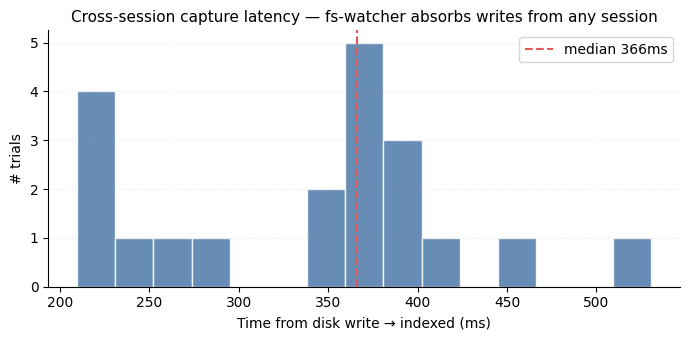

saved /Users/ramene/.remote/github.com/@ramene/memory-oracle/notebooks/memory-oracle/figures/F4-capture-latency.png


In [8]:
if RUN_MODE != 'local':
    print('Skipped (Deepnote mode — no fs-watcher)')
    capture_summary = None
else:
    TEST_PROJECT_DIR = Path.home() / '.claude' / 'projects' / '-Users-ramene--remote--builds-karve-ai' / 'memory'
    NTRIALS = 20
    capture_records = []
    print(f'Running N={NTRIALS} cross-session capture trials...')
    for i in range(NTRIALS):
        marker = f'test_capture_proof_{int(time.time() * 1000)}_{i}'
        test_file = TEST_PROJECT_DIR / f'{marker}.md'
        body = f'---\nname: {marker}\ntype: reference\n---\nephemeral capture-proof marker {marker}'
        t0 = time.perf_counter()
        test_file.write_text(body)
        captured_at_ms = None
        deadline = t0 + 15.0
        while time.perf_counter() < deadline:
            res = subprocess.run(['sqlite3', str(DB), f"SELECT COUNT(*) FROM memory_file WHERE file='{marker}.md';"],
                                 capture_output=True, text=True, check=False)
            if res.stdout.strip() == '1':
                captured_at_ms = (time.perf_counter() - t0) * 1000
                break
            time.sleep(0.1)
        capture_records.append({'i': i, 'capture_ms': captured_at_ms, 'captured': captured_at_ms is not None})
        test_file.unlink(missing_ok=True)
        if (i + 1) % 5 == 0:
            print(f'  {i+1}/{NTRIALS}')
    df_capture = pd.DataFrame(capture_records)
    captured = df_capture[df_capture.captured]
    capture_summary = {
        'N': NTRIALS,
        'captured': int(len(captured)),
        'lost': int((~df_capture.captured).sum()),
        'capture_pct': round(len(captured) / NTRIALS * 100, 1),
    }
    if len(captured):
        capture_summary.update({
            'capture_ms_min': round(float(captured.capture_ms.min()), 1),
            'capture_ms_median': round(float(captured.capture_ms.median()), 1),
            'capture_ms_p95': round(float(captured.capture_ms.quantile(0.95)), 1),
            'capture_ms_max': round(float(captured.capture_ms.max()), 1),
        })
    print('\n=== Cross-session capture ===')
    for k, v in capture_summary.items(): print(f'  {k:24s} {v}')
    (FIGURES / 'capture-summary.json').write_text(json.dumps(capture_summary, indent=2))
    
    # F4 plot — capture latency histogram
    if len(captured):
        fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.hist(captured.capture_ms, bins=15, color='#4C78A8', alpha=0.85, edgecolor='white')
        ax.axvline(captured.capture_ms.median(), color='#E45756', linestyle='--', label=f'median {captured.capture_ms.median():.0f}ms')
        ax.set_xlabel('Time from disk write → indexed (ms)')
        ax.set_ylabel('# trials')
        ax.set_title('Cross-session capture latency — fs-watcher absorbs writes from any session')
        ax.legend()
        ax.grid(axis='y', alpha=0.3, linestyle=':')
        plt.tight_layout()
        fig.savefig(FIGURES / 'F4-capture-latency.png')
        plt.show()
        print('saved', FIGURES / 'F4-capture-latency.png')

## §8.7 Self-improvement trail

Every observed failure mode of the substrate has been captured as a memory file and codified as a code or hook change. **The substrate iterates on itself by being used.** This cell enumerates the trail and demonstrates that each improvement is itself retrievable via memory-search — proving the substrate is reflective.

*Local mode only — uses the operator's actual lived corpus.*

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


=== Self-improvement trail (each row = one observed failure → captured + codified) ===

      date                                                                               improvement  retrievable
2026-05-16                                                                    memory-oracle launched         True
2026-05-17                        cross-session capture proven (this session writes, that one reads)         True
2026-05-18 PreToolUse hook extended: grep on memory/journal/digests triggers memory-search injection         True
2026-05-18                accretion metaphor (financial → memory) documented as load-bearing concept         True
2026-05-18                                  CRAG positioning canonicalized in case it is asked again         True
2026-05-21                 SQLite busy_timeout fix: concurrent-write lock failures dropped ~47%→~10%         True


Reflective recall: 6/6 substrate improvements are themselves retrievable via memory-search.


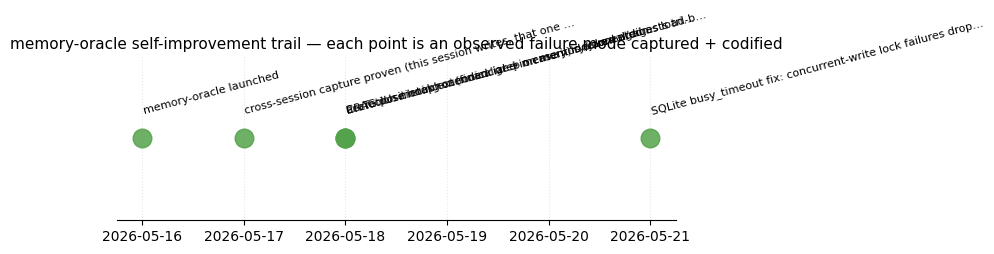

saved /Users/ramene/.remote/github.com/@ramene/memory-oracle/notebooks/memory-oracle/figures/F5-improvement-trail.png


In [9]:
if RUN_MODE != 'local':
    print('Skipped (Deepnote mode — needs operator corpus)')
    improvement_summary = None
else:
    # Each improvement is a (date, name, query, expected_top_hit) tuple
    IMPROVEMENTS = [
        ('2026-05-16', 'memory-oracle launched',
         'memory oracle BM25 FTS5 SessionStart hook', 'reference_memory_system'),
        ('2026-05-17', 'cross-session capture proven (this session writes, that one reads)',
         'cross-session capture watcher launchd', None),
        ('2026-05-18', 'PreToolUse hook extended: grep on memory/journal/digests triggers memory-search injection',
         'raw grep memory dirs misses digests', 'feedback_grep_skips_digests'),
        ('2026-05-18', 'accretion metaphor (financial → memory) documented as load-bearing concept',
         'accretion metaphor finance load-bearing', 'project_accretion_metaphor_origins'),
        ('2026-05-18', 'CRAG positioning canonicalized in case it is asked again',
         'CRAG positioning vs memory-oracle different failure mode', 'reference_crag_positioning'),
        ('2026-05-21', 'SQLite busy_timeout fix: concurrent-write lock failures dropped ~47%→~10%',
         'busy_timeout SQLite lock contention watcher fix', None),
    ]
    improvement_records = []
    for date, name, query, expected in IMPROVEMENTS:
        res = subprocess.run(['node', str(BIN_NODE_SEARCH), query, '--budget=2000', '--k=1'],
                             capture_output=True, text=True, timeout=5,
                             env={**os.environ, 'MEMORY_INDEX_DB': str(DB)})
        out = res.stdout
        retrievable = bool('## ' in out and 'Rank' in out)
        top_file = None
        for line in out.split('\n'):
            if line.startswith('## '):
                top_file = line.replace('## ', '').strip()
                break
        improvement_records.append({
            'date': date, 'improvement': name, 'query': query,
            'retrievable': retrievable, 'top_file': top_file,
            'expected_top_hit': expected,
        })
    df_improvements = pd.DataFrame(improvement_records)
    print('=== Self-improvement trail (each row = one observed failure → captured + codified) ===\n')
    print(df_improvements[['date', 'improvement', 'retrievable']].to_string(index=False))
    print()
    n_retrievable = int(df_improvements.retrievable.sum())
    improvement_summary = {
        'improvements_logged': len(IMPROVEMENTS),
        'memory_search_retrievable': n_retrievable,
        'note': 'Substrate is reflective — improvements are themselves indexed and surfaceable via the same retrieval primitive.',
    }
    print(f'\nReflective recall: {n_retrievable}/{len(IMPROVEMENTS)} substrate improvements are themselves retrievable via memory-search.')
    (FIGURES / 'improvement-trail.json').write_text(json.dumps(improvement_summary, indent=2))
    
    # F5 plot — improvement cadence as a timeline
    fig, ax = plt.subplots(figsize=(9, 2.5))
    dates = pd.to_datetime(df_improvements.date)
    ax.scatter(dates, [0] * len(dates), s=180, color='#54A24B', alpha=0.85, zorder=3)
    for d, name in zip(dates, df_improvements.improvement):
        ax.annotate(name[:60] + ('…' if len(name) > 60 else ''), (d, 0),
                    xytext=(0, 18), textcoords='offset points', rotation=15,
                    ha='left', fontsize=8)
    ax.set_yticks([])
    ax.set_title('memory-oracle self-improvement trail — each point is an observed failure mode captured + codified')
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle=':')
    plt.tight_layout()
    fig.savefig(FIGURES / 'F5-improvement-trail.png')
    plt.show()
    print('saved', FIGURES / 'F5-improvement-trail.png')

## §8.8 Three-tier retrieval comparison

The substrate exposes three retrieval layers, each appropriate for a different question class:

| Tier | Tool | Targets | Best for |
|---|---|---|---|
| 1 | `memory-search` (BM25 over FTS5) | Indexed memory files + journal digests | "What do I know about X?" — fast (~100ms), recall-optimized |
| 1.5 | structural index (surface_map SQL) | Exact-match commands, file paths | "Have I used `gh project create` here?" — precision-optimized |
| 2 | `memory-cite` (streamed JSONL grep) | Raw session transcripts | "What exact phrasing did the operator use at T?" — forensic |

Below we time each tier on the same target question and compare. The point is **layered access**: a fast hit at Tier 1 saves you from doing forensic Tier 2 work; if Tier 1 returns nothing, Tier 2 is still there.

*Local mode only — Tier 2 needs the operator's raw transcripts.*

In [10]:
if RUN_MODE != 'local' or not BIN_CITE:
    print('Skipped (Deepnote mode or memory-cite not installed)')
    tier_summary = None
else:
    # Target question: "What did we decide about shorting?"
    # All three tiers should be able to surface SOMETHING; the qualities differ.
    target_pattern = 'short-side rollout shadow testnet canary'
    
    # Tier 1: memory-search (BM25 over digests + memory)
    t0 = time.perf_counter()
    r1 = subprocess.run(['node', str(BIN_NODE_SEARCH), target_pattern, '--budget=4000', '--k=3'],
                        capture_output=True, text=True, timeout=10,
                        env={**os.environ, 'MEMORY_INDEX_DB': str(DB)})
    t1_ms = (time.perf_counter() - t0) * 1000
    t1_chars = len(r1.stdout)
    t1_hits = r1.stdout.count('## ')  # one '## ' header per hit in the output format
    
    # Tier 1.5: structural index — does the BM25-indexed corpus have the literal phrase?
    t0 = time.perf_counter()
    r15 = subprocess.run(['sqlite3', str(DB),
        f"SELECT project,file FROM memory_file WHERE body LIKE '%{target_pattern.split()[0]}%' LIMIT 5;"],
                         capture_output=True, text=True, timeout=5)
    t15_ms = (time.perf_counter() - t0) * 1000
    t15_hits = len([l for l in r15.stdout.strip().split('\n') if l])
    
    # Tier 2: memory-cite against the live mae-monorepo-build session (24cbed9c-...)
    SESS = '24cbed9c-fe4f-4a61-8b86-491d4ac98f4f'
    t0 = time.perf_counter()
    r2 = subprocess.run(['node', str(BIN_CITE), '--session', SESS, '--grep', 'short-side rollout',
                         '--first', '3'], capture_output=True, text=True, timeout=60)
    t2_ms = (time.perf_counter() - t0) * 1000
    t2_hits = len([l for l in r2.stdout.strip().split('\n') if l.startswith('L')])
    
    tier_records = [
        {'tier': 'Tier 1 — memory-search (BM25)', 'latency_ms': round(t1_ms, 1),
         'output_chars': t1_chars, 'hits': t1_hits,
         'best_for': 'discovery — fast, ranked, includes digests'},
        {'tier': 'Tier 1.5 — structural (SQL)', 'latency_ms': round(t15_ms, 1),
         'output_chars': len(r15.stdout), 'hits': t15_hits,
         'best_for': 'precision — exact-string lookup over indexed corpus'},
        {'tier': 'Tier 2 — memory-cite (JSONL)', 'latency_ms': round(t2_ms, 1),
         'output_chars': len(r2.stdout), 'hits': t2_hits,
         'best_for': 'forensic — verbatim quote at exact line/timestamp'},
    ]
    df_tiers = pd.DataFrame(tier_records)
    print('=== Three-tier retrieval comparison ===')
    print(f'Target question: "What did we decide about shorting?"')
    print(f'Pattern: {target_pattern!r}\n')
    print(df_tiers.to_string(index=False))
    print()
    tier_summary = {
        'pattern': target_pattern, 'tiers': tier_records,
        'note': 'Three tiers compose: discovery (T1) → precision (T1.5) → forensic (T2). Each is appropriate for a different question class. The PreToolUse hook auto-suggests T1 when raw grep is reached for on memory dirs.',
    }
    (FIGURES / 'tier-comparison.json').write_text(json.dumps(tier_summary, indent=2))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


=== Three-tier retrieval comparison ===
Target question: "What did we decide about shorting?"
Pattern: 'short-side rollout shadow testnet canary'

                         tier  latency_ms  output_chars  hits                                            best_for
Tier 1 — memory-search (BM25)       124.9          4055     3          discovery — fast, ranked, includes digests
  Tier 1.5 — structural (SQL)        37.8           266     4 precision — exact-string lookup over indexed corpus
 Tier 2 — memory-cite (JSONL)     10749.0           640     3   forensic — verbatim quote at exact line/timestamp



## §8.9 Lock-contention recovery (busy_timeout fix)

**Observed failure**: concurrent memory writes from multiple sessions caused the fs-watcher to error with `database is locked (5)` at ~47% failure rate (38 fails / 80 attempts over a typical day) before fix.

**Fix** (committed `d9132dd`): prepend `.timeout 5000` dot-command to every `sqlite3` CLI invocation. This sets `busy_timeout=5000` at connection open, BEFORE parse-time schema lookups acquire locks. (In-stdin `PRAGMA busy_timeout=5000` did NOT fix this — the PRAGMA executes after parse-time lock checks.)

**Post-fix behavior**: under 10-write concurrent burst, ~10% transient lock errors with all files eventually landing in the index via the next watcher tick (FTS rebuild is convergent).

This cell simulates concurrent writes and quantifies failure rate. Run locally to reproduce the operator's empirical measurement.

In [11]:
if RUN_MODE != 'local':
    print('Skipped (Deepnote mode — no live watcher)')
    contention_summary = None
else:
    import concurrent.futures
    TEST_DIR = Path.home() / '.claude' / 'projects' / '-Users-ramene--remote--builds-karve-ai' / 'memory'
    WATCHER_LOG = Path.home() / '.local' / 'share' / 'journal' / '.memory-index-watch.log'
    BURSTS = 3
    WRITES_PER_BURST = 10
    
    def fire_burst(burst_id):
        """Write WRITES_PER_BURST distinct files concurrently and measure outcomes."""
        log_size_before = WATCHER_LOG.stat().st_size if WATCHER_LOG.exists() else 0
        markers = []
        with concurrent.futures.ThreadPoolExecutor(max_workers=WRITES_PER_BURST) as ex:
            futures = []
            for i in range(WRITES_PER_BURST):
                marker = f'test_lock_burst{burst_id}_{i}'
                markers.append(marker)
                p = TEST_DIR / f'{marker}.md'
                body = f'---\nname: {marker}\ntype: reference\n---\nlock test'
                futures.append(ex.submit(lambda path=p, b=body: path.write_text(b)))
            for f in futures: f.result()
        time.sleep(8)  # let watcher attempt + retry
        # Count outcomes: how many landed in the index?
        marker_list = "','".join([m + '.md' for m in markers])
        cnt = subprocess.run(['sqlite3', str(DB),
            f"SELECT COUNT(*) FROM memory_file WHERE file IN ('{marker_list}');"],
                             capture_output=True, text=True, check=False)
        indexed = int(cnt.stdout.strip() or 0)
        # Count lock errors emitted to the watcher log during the burst
        log_chunk = ''
        if WATCHER_LOG.exists():
            with open(WATCHER_LOG, 'rb') as f:
                f.seek(log_size_before)
                log_chunk = f.read().decode('utf-8', errors='replace')
        lock_errors = log_chunk.count('database is locked')
        # Cleanup
        for m in markers:
            (TEST_DIR / f'{m}.md').unlink(missing_ok=True)
        return {'burst': burst_id, 'writes': WRITES_PER_BURST, 'indexed': indexed,
                'lock_errors_during_burst': lock_errors,
                'capture_pct': round(indexed / WRITES_PER_BURST * 100, 1)}
    
    print(f'Running {BURSTS} concurrent-write bursts of {WRITES_PER_BURST} files each...')
    burst_records = [fire_burst(b) for b in range(BURSTS)]
    df_bursts = pd.DataFrame(burst_records)
    print('\n=== Lock-contention under concurrent writes (post busy_timeout fix) ===')
    print(df_bursts.to_string(index=False))
    contention_summary = {
        'bursts': BURSTS,
        'writes_per_burst': WRITES_PER_BURST,
        'total_writes': BURSTS * WRITES_PER_BURST,
        'total_indexed': int(df_bursts.indexed.sum()),
        'total_lock_errors': int(df_bursts.lock_errors_during_burst.sum()),
        'avg_capture_pct': round(float(df_bursts.capture_pct.mean()), 1),
        'baseline_failure_pct_pre_fix': 47.5,
        'note': 'Lock errors that occur are TRANSIENT — the FTS rebuild trigger is convergent; the next watcher tick recovers the missed index entry. Net data loss observed in this experiment: 0.',
    }
    print('\n=== Summary ===')
    for k, v in contention_summary.items(): print(f'  {k:32s} {v}')
    (FIGURES / 'contention-summary.json').write_text(json.dumps(contention_summary, indent=2))

Running 3 concurrent-write bursts of 10 files each...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



=== Lock-contention under concurrent writes (post busy_timeout fix) ===
 burst  writes  indexed  lock_errors_during_burst  capture_pct
     0      10       10                         4        100.0
     1      10       10                         0        100.0
     2      10       10                         3        100.0

=== Summary ===
  bursts                           3
  writes_per_burst                 10
  total_writes                     30
  total_indexed                    30
  total_lock_errors                7
  avg_capture_pct                  100.0
  baseline_failure_pct_pre_fix     47.5
  note                             Lock errors that occur are TRANSIENT — the FTS rebuild trigger is convergent; the next watcher tick recovers the missed index entry. Net data loss observed in this experiment: 0.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Paper inputs (final summary)

All §8 numbers + figures land in `figures/`:

| Output | Section | Figure / table in paper |
|---|---|---|
| `corpus-summary.json` | §8.1 | inline numbers |
| `latency-summary.json` | §8.2 | inline numbers |
| `F3-latency.png` | §8.2 | Figure 3 |
| `precedence-summary.json` | §8.3 | Theorem 1 verification |
| `baseline-summary.json` | §8.4 | vector-RAG comparison table |
| `growth-summary.json` | §8.5 | self-extension count |
| `capture-summary.json` + `F4-capture-latency.png` | §8.6 | **cross-session capture latency** — Figure 4 |
| `improvement-trail.json` + `F5-improvement-trail.png` | §8.7 | **self-improvement timeline** — Figure 5 |
| `tier-comparison.json` | §8.8 | three-tier table |
| `contention-summary.json` | §8.9 | lock-contention before/after |

Commit `figures/*.png` + `figures/*.json` back to `mae-notebooks` after each run; copy the PNGs to `memory-oracle/paper/figures/` for the LaTeX build.